In [2]:
#%pip install scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Data Loading

In [6]:
X_train_resampled = pd.read_csv("Data/X_train_resampled.csv")
y_train_resampled = pd.read_csv("Data/y_train_resampled.csv").squeeze()
X_val_scaled = pd.read_csv("Data/X_val_scaled.csv")
y_val = pd.read_csv("Data/y_val.csv").squeeze()
X_test_scaled = pd.read_csv("Data/X_test_scaled.csv")
y_test = pd.read_csv("Data/y_test.csv").squeeze()
print("Loaded preprocessed splits.")

Loaded preprocessed splits.


## Logistic Regression: Tuning and Training

In [7]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

lr_grid = GridSearchCV(
    lr_base,
    lr_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_resampled, y_train_resampled)

print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV AUC: {lr_grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV AUC: 0.8436


## Logistic Regression: Validation Results

In [8]:
lr_best = lr_grid.best_estimator_

lr_val_preds = lr_best.predict(X_val_scaled)
lr_val_probs = lr_best.predict_proba(X_val_scaled)[:, 1]

print("=== Logistic Regression — Validation Set Results ===\n")
print(classification_report(y_val, lr_val_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_val, lr_val_probs):.4f}")
print(f"F1:        {f1_score(y_val, lr_val_preds):.4f}")
print(f"Precision: {precision_score(y_val, lr_val_preds):.4f}")
print(f"Recall:    {recall_score(y_val, lr_val_preds):.4f}")
print(lr_grid.best_params_)

=== Logistic Regression — Validation Set Results ===

               precision    recall  f1-score   support

        No HD       0.97      0.74      0.84     30910
Heart Disease       0.25      0.77      0.38      3557

     accuracy                           0.74     34467
    macro avg       0.61      0.75      0.61     34467
 weighted avg       0.89      0.74      0.79     34467

AUC-ROC:   0.8351
F1:        0.3826
Precision: 0.2547
Recall:    0.7689
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


## Logistic Regression: Confusion Matrix

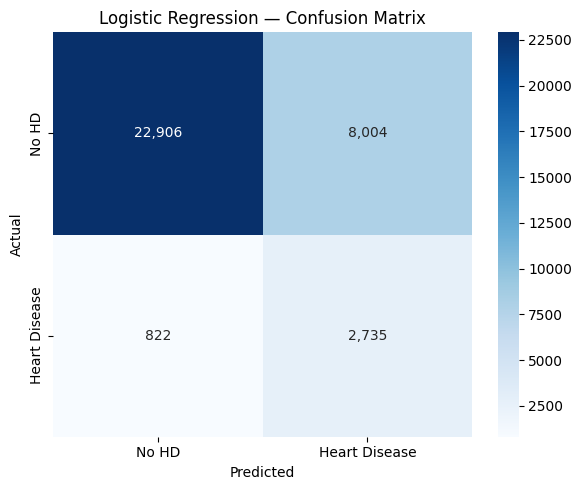

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, lr_val_preds)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['No HD', 'Heart Disease'],
            yticklabels=['No HD', 'Heart Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

## Logistic Regression: ROC Curve

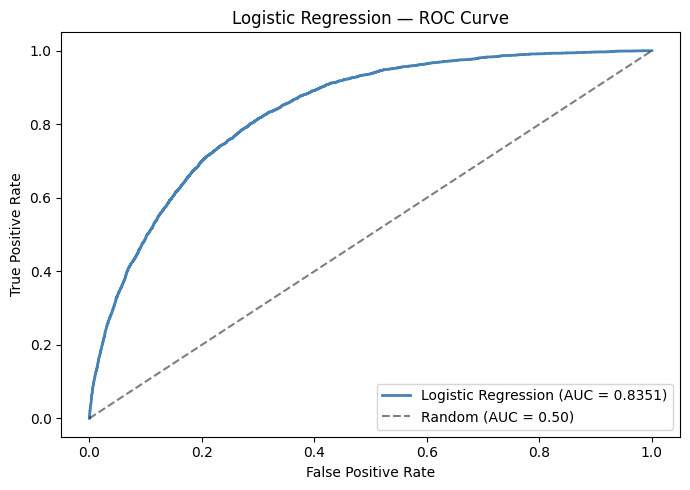

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_val_probs)
lr_auc = roc_auc_score(y_val, lr_val_probs)
ax.plot(lr_fpr, lr_tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression — ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## Logistic Regression: Feature Coefficients

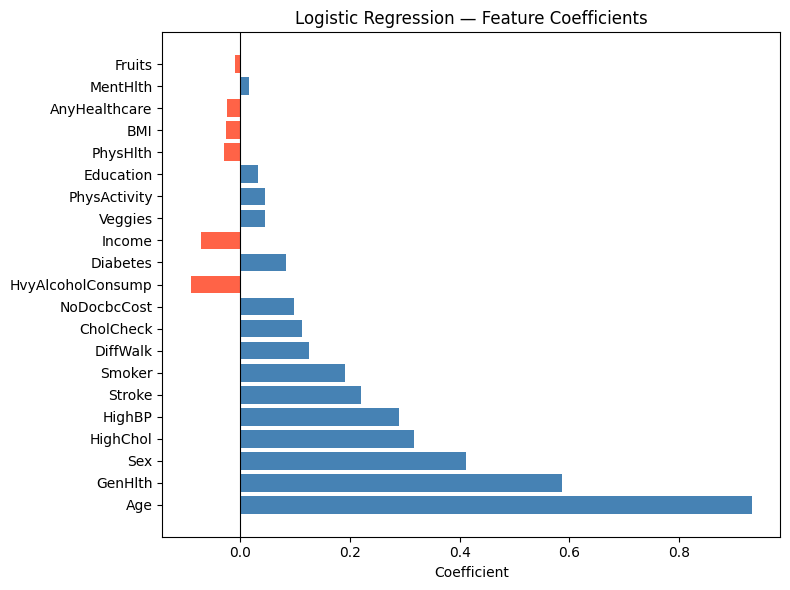

          Feature  Coefficient
              Age     0.932595
          GenHlth     0.585828
              Sex     0.410850
         HighChol     0.317141
           HighBP     0.289356
           Stroke     0.219985
           Smoker     0.191709
         DiffWalk     0.125158
        CholCheck     0.112321
      NoDocbcCost     0.098935
HvyAlcoholConsump    -0.090104
         Diabetes     0.083383
           Income    -0.070585
          Veggies     0.045680
     PhysActivity     0.044874
        Education     0.033585
         PhysHlth    -0.029565
              BMI    -0.025660
    AnyHealthcare    -0.023244
         MentHlth     0.016901
           Fruits    -0.009895


In [11]:
coef_df = pd.DataFrame({
    'Feature': X_train_resampled.columns,
    'Coefficient': lr_best.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression — Feature Coefficients')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## Logistic Regression: Final Test Set Evaluation

In [12]:
lr_test_preds = lr_best.predict(X_test_scaled)
lr_test_probs = lr_best.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression — Test Set Results ===\n")
print(classification_report(y_test, lr_test_preds, target_names=['No HD', 'Heart Disease']))
print(f"AUC-ROC:   {roc_auc_score(y_test, lr_test_probs):.4f}")
print(f"F1:        {f1_score(y_test, lr_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_test_preds):.4f}")

=== Logistic Regression — Test Set Results ===

               precision    recall  f1-score   support

        No HD       0.97      0.74      0.84     30910
Heart Disease       0.26      0.79      0.39      3558

     accuracy                           0.74     34468
    macro avg       0.61      0.76      0.61     34468
 weighted avg       0.89      0.74      0.79     34468

AUC-ROC:   0.8377
F1:        0.3873
Precision: 0.2570
Recall:    0.7853


## Observations

- `C=0.01`, `L2` penalty — the low C value means strong regularization, suggesting the model benefits from being kept simple on this dataset
- The model correctly identifies 77% of heart disease cases (recall = 0.77) but only 25% of its positive predictions are correct (precision = 0.25). This means many healthy patients are flagged as at-risk
- Despite the precision/recall imbalance, the model has good overall discriminative ability, as it ranks true positives above true negatives most of the time
- Training on balanced (50/50) SMOTE data caused the model to predict heart disease more aggressively on the real-world imbalanced validation set (~10% positive), driving up recall at the cost of precision
- Validation and test results are nearly identical (AUC 0.8351 vs. 0.8377, F1 0.38 vs. 0.39), indicating the model generalizes well and is not overfit
- For a medical screening task, high recall is generally preferable to high precision, since missing a true heart disease case is more costly than a false alarm. This model's recall-heavy behavior may actually be desirable